# Basic usage example for simulating PEN DNA systems

You will need two elements from the Python side:
- A representation of your system (DACCADIndividual)
- A wrapper for the DACCAD simulator

In this example, we will simulate a basic Oligator (chemical oscillator) with the Jpype wrapper.

In [1]:
from daccadevo.core import DaccadIndividual, evaluate_timeseries
from daccadevo.wrappers import Jpype_wrapper
import matplotlib.pyplot as plt
import numpy as np

In [2]:
indiv = DaccadIndividual([0,1])
indiv.resize(3) # We need two signal species
indiv.stabilities = np.array([74.328, 74.328, 74.328]) # represent the stabilities of signal sequences on their templates
indiv.activations = np.array([[10.0,10.0,0.0],[0.0,0.0,10.0],[0.0,0.0,0.0]]) # 0 -> 0, 0 -> 1 activations of signals
indiv.inhibitions = np.zeros((3,3,3))
indiv.inhibitions[2,0,0] = 10.0 # 2 -> Inh -| (0 -> 0) 1 triggers the production of the inhibitor of 0 -> 0
indiv.assemble() # compile all informations into a single array representation

In [3]:
# Basic wrapper and DACCAD configurations
# Not specifying anything would use defaults
config = {'debug': False, 
          'dataDir': '.', 'daccad': {'config_file':'./short.conf' ,
                                     'executable_path':'../../daccad'}
         }

In [4]:
wrapper = Jpype_wrapper(config=config)

In [5]:
initConc = [0.0 for _ in range(indiv.nb_nodes)]
initConc[0] = 0.1 # initial conditions

In [6]:
results = evaluate_timeseries(indiv,config=config, initConc=initConc,wrapper=wrapper, scales=[1.0,1.0])

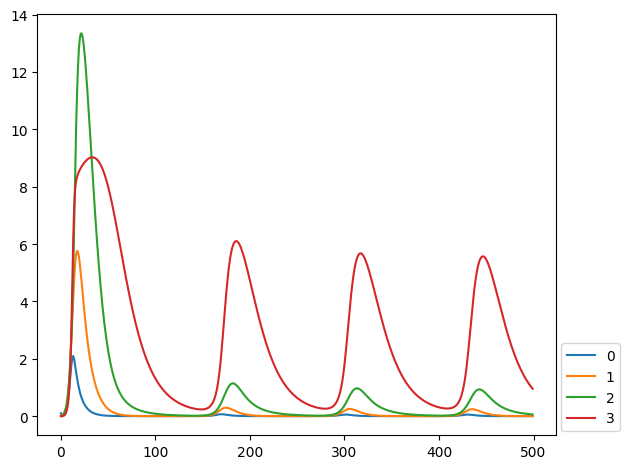

In [7]:
plt.plot(results[:,:indiv.nb_nodes+1]) # Plot the inhibitor as well
ax = plt.gca()
ax.legend([str(i) for i in range(indiv.nb_nodes+1)],loc=(1.01, 0.01))
plt.tight_layout()